In [37]:
import pandas as pd
import numpy as np
import re

In [38]:
# Load all years
years = [2015, 2016, 2017, 2018, 2019, 2023, 2024]

cps_list, act_list, resp_list = [], [], []
for yr in years:
    cps_list.append(pd.read_csv(f"../data/atuscps_{yr}.dat"))
    act_list.append(pd.read_csv(f"../data/atussum_{yr}.dat"))
    resp_list.append(pd.read_csv(f"../data/atusresp_{yr}.dat"))

# Stack years together (use shared columns only in case they differ across years)
shared_cps_cols = list(set.intersection(*[set(d.columns) for d in cps_list]))
cps = pd.concat([d[shared_cps_cols] for d in cps_list], ignore_index=True)

shared_act_cols = list(set.intersection(*[set(d.columns) for d in act_list]))
act_sum = pd.concat([d[shared_act_cols] for d in act_list], ignore_index=True)

shared_resp_cols = list(set.intersection(*[set(d.columns) for d in resp_list]))
resp = pd.concat([d[shared_resp_cols] for d in resp_list], ignore_index=True)

print("CPS:", cps.shape)
print("Activity Summary:", act_sum.shape)
print("Respondent:", resp.shape)

CPS: (453448, 364)
Activity Summary: (66866, 345)
Respondent: (66866, 174)


In [39]:
# --- Pull occupation from CPS (keep one row per person) ---
cps_person = cps[cps["TULINENO"] == 1][["TUCASEID", "PRMJOCC1"]].copy()

# --- Pull diary date and detailed occupation from respondent file ---
resp_vars = resp[["TUCASEID", "TUDIARYDATE", "TRDTOCC1"]].copy()

# --- Merge activity summary with CPS occupation and respondent vars ---
df = act_sum.merge(cps_person, on="TUCASEID", how="left")
df = df.merge(resp_vars, on="TUCASEID", how="left")

# --- Filter to ages 19-26 ---
df = df[(df["TEAGE"] >= 19) & (df["TEAGE"] <= 26)].copy()

# --- Classify groups ---
# TESCHENR: 1 = enrolled in school, 2 = not enrolled
# TESCHLVL: 2 = college/university
# PEEDUCA: >= 43 means bachelor's degree or higher
# TELFS: 1 = employed full-time, 2 = employed part-time

conditions = {
    "Undergrad": (df["TESCHENR"] == 1) & (df["TESCHLVL"] == 2) & (df["PEEDUCA"] < 43),
    "Graduate": (df["TESCHENR"] == 1) & (df["TESCHLVL"] == 2) & (df["PEEDUCA"] >= 43),
    "Employed": (df["TESCHENR"] == 2) & (df["TELFS"].isin([1, 2])) & (df["PEEDUCA"] >= 43),
}

df["group"] = "Other"
for label, mask in conditions.items():
    df.loc[mask, "group"] = label

# --- Drop anyone who didn't fit a group ---
df = df[df["group"] != "Other"].copy()

# --- Collect activity columns (all start with "t" followed by digits) ---
activity_cols = [c for c in df.columns if c.startswith("t") and c[1:2].isdigit()]

# --- Build final dataset ---
analysis_df = df[["TUCASEID", "group", "TEAGE", "TESEX", "PRMJOCC1", "TRDTOCC1", "TUDIARYDAY", "TUDIARYDATE"] + activity_cols].copy()

print(f"Final shape: {analysis_df.shape}")
print(f"\nGroup counts:")
print(analysis_df["group"].value_counts())

print(f"\nSex counts:")
print(analysis_df["TESEX"].value_counts())

analysis_df.head()

Final shape: (2094, 329)

Group counts:
group
Undergrad    1044
Employed      830
Graduate      220
Name: count, dtype: int64

Sex counts:
TESEX
2    1150
1     944
Name: count, dtype: int64


,TUCASEID,group,TEAGE,TESEX,PRMJOCC1,TRDTOCC1,TUDIARYDAY,TUDIARYDATE,t150402,t080401,...,t130104,t180699,t020602,t040102,t130102,t120403,t160103,t180404,t150204,t050399
27,20150101150794,Undergrad,19,2,3,-1,6,20150130,0,0,...,0,0,0,0,0,0,0,0,0,0
45,20150101150989,Graduate,23,1,2,8,1,20150125,0,0,...,0,0,0,0,0,0,0,0,0,0
82,20150101151505,Undergrad,19,1,-1,-1,1,20150125,0,0,...,0,0,0,0,0,0,0,0,0,0
85,20150101151539,Employed,25,2,1,1,4,20150128,0,0,...,0,0,0,0,0,0,0,0,0,0
127,20150101152146,Undergrad,19,2,-1,-1,7,20150131,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
analysis_df.columns

Index(['TUCASEID', 'group', 'TEAGE', 'TESEX', 'PRMJOCC1', 'TRDTOCC1',
       'TUDIARYDAY', 'TUDIARYDATE', 't150402', 't080401',
       ...
       't130104', 't180699', 't020602', 't040102', 't130102', 't120403',
       't160103', 't180404', 't150204', 't050399'],
      dtype='object', length=329)

In [41]:
# Group all time columns into activity categories

# all ATUS time columns, like t010101, t050101, etc.
activity_cols = [c for c in analysis_df.columns if re.match(r"^t\d{6}$", c)]

# mapping from highest-level ATUS code to readable label
major_code_map = {
    "01": "personal_care",
    "02": "household_activities",
    "03": "caring_for_hh_members",
    "04": "caring_for_nonhh_members",
    "05": "work_and_work_related",
    "06": "education",
    "07": "consumer_purchases",
    "08": "professional_and_personal_services",
    "09": "household_services",
    "10": "government_services_and_civic",
    "11": "eating_and_drinking",
    "12": "socializing_relaxing_leisure",
    "13": "sports_exercise_recreation",
    "14": "religious_spiritual_activities",
    "15": "volunteer_activities",
    "16": "telephone_calls",
    "18": "traveling",
    "50": "data_codes"
}

# group columns by their first 2 digits after the "t"
major_groups = {}
for col in activity_cols:
    major_code = col[1:3]   # e.g. t010101 -> "01"
    major_groups.setdefault(major_code, []).append(col)

# sum within each highest-level category
final_df = analysis_df[["TUCASEID", "group", "TEAGE", "TESEX", "PRMJOCC1", "TRDTOCC1"]].copy()

# Extract survey year from TUCASEID (first 4 digits encode the year)
final_df["year"] = final_df["TUCASEID"].astype(str).str[:4].astype(int)

# --- Weekend vs Weekday ---
# TUDIARYDAY: 1=Sunday, 2=Monday, ..., 6=Friday, 7=Saturday
final_df["is_weekend"] = analysis_df["TUDIARYDAY"].isin([1, 7]).astype(int)

# --- Break vs Semester ---
# Extract month and day from TUDIARYDATE (YYYYMMDD format)
diary_month = (analysis_df["TUDIARYDATE"] // 100) % 100
diary_day = analysis_df["TUDIARYDATE"] % 100
# Summer break: May 15+ through August
# Winter break: Dec 15+ through Jan 14
# Semester: everything else
is_summer = diary_month.isin([6, 7, 8]) | ((diary_month == 5) & (diary_day >= 15))
is_winter_dec = (diary_month == 12) & (diary_day >= 15)
is_winter_jan = (diary_month == 1) & (diary_day <= 14)
final_df["is_break"] = (is_summer | is_winter_dec | is_winter_jan).astype(int)

for code, cols in major_groups.items():
    new_name = major_code_map.get(code, f"code_{code}")
    final_df[new_name] = analysis_df[cols].sum(axis=1)

print(f"Year counts:\n{final_df['year'].value_counts()}")
print(f"\nWeekend vs Weekday:\n{final_df['is_weekend'].value_counts().rename({0: 'Weekday', 1: 'Weekend'})}")
print(f"\nBreak vs Semester:\n{final_df['is_break'].value_counts().rename({0: 'Semester', 1: 'Break'})}")
print(f"\nGroup counts:\n{final_df['group'].value_counts()}")
final_df.head()

Year counts:
year
2015    350
2016    336
2019    296
2018    284
2017    283
2024    275
2023    270
Name: count, dtype: int64

Weekend vs Weekday:
is_weekend
Weekend    1063
Weekday    1031
Name: count, dtype: int64

Break vs Semester:
is_break
Semester    1345
Break        749
Name: count, dtype: int64

Group counts:
group
Undergrad    1044
Employed      830
Graduate      220
Name: count, dtype: int64


,TUCASEID,group,TEAGE,TESEX,PRMJOCC1,TRDTOCC1,year,is_weekend,is_break,volunteer_activities,...,socializing_relaxing_leisure,telephone_calls,household_services,government_services_and_civic,religious_spiritual_activities,consumer_purchases,personal_care,education,data_codes,eating_and_drinking
27,20150101150794,Undergrad,19,2,3,-1,2015,0,0,0,...,240,0,0,0,0,0,600,210,60,90
45,20150101150989,Graduate,23,1,2,8,2015,1,0,0,...,495,0,0,0,0,0,530,0,0,35
82,20150101151505,Undergrad,19,1,-1,-1,2015,1,0,0,...,450,0,0,0,0,0,750,160,20,20
85,20150101151539,Employed,25,2,1,1,2015,0,0,0,...,250,0,0,0,0,0,565,0,0,20
127,20150101152146,Undergrad,19,2,-1,-1,2015,1,0,0,...,20,0,0,0,0,0,540,690,0,120


In [42]:
# --- Check ambiguous transition dates (undergrad + grad only) ---
student_mask = analysis_df["group"].isin(["Undergrad", "Graduate"])
student_df = analysis_df[student_mask]

diary_month = (student_df["TUDIARYDATE"] // 100) % 100
diary_day = student_df["TUDIARYDATE"] % 100

ambiguous = (
    ((diary_month == 5) & (diary_day <= 14)) |                        # May 1-14
    ((diary_month == 8) & (diary_day >= 15)) | (diary_month == 9) |   # Aug 15 - Sep 30
    ((diary_month == 1) & (diary_day >= 5) & (diary_day <= 14)) |     # Jan 5-14
    ((diary_month == 1) & (diary_day >= 15)) | ((diary_month == 2) & (diary_day <= 2)) |  # Jan 15 - Feb 2
    ((diary_month == 12) & (diary_day >= 13) & (diary_day <= 20))     # Dec 13-20
)

n_ambiguous = ambiguous.sum()
n_students = len(student_df)
n_total = len(analysis_df)

print(f"Ambiguous transition-period data points (Undergrad + Grad only): {n_ambiguous}")
print(f"  As % of all data:              {n_ambiguous / n_total:.3f} ({n_ambiguous / n_total * 100:.1f}%)")
print(f"  As % of undergrad+grad only:   {n_ambiguous / n_students:.3f} ({n_ambiguous / n_students * 100:.1f}%)")

# Breakdown by period
periods = {
    "May 1-14 (end of spring)": (diary_month == 5) & (diary_day <= 14),
    "Aug 15 - Sep 30 (fall start)": ((diary_month == 8) & (diary_day >= 15)) | (diary_month == 9),
    "Jan 5-14 (pre-spring, in break)": (diary_month == 1) & (diary_day >= 5) & (diary_day <= 14),
    "Jan 15 - Feb 2 (spring start)": ((diary_month == 1) & (diary_day >= 15)) | ((diary_month == 2) & (diary_day <= 2)),
    "Dec 13-20 (finals/break edge)": (diary_month == 12) & (diary_day >= 13) & (diary_day <= 20),
}

print(f"\nBreakdown (Undergrad + Grad):")
print(f"  {'Period':<40} {'n':>5}  {'% of all':>8}  {'% of students':>13}")
print(f"  {'-'*40} {'-'*5}  {'-'*8}  {'-'*13}")
for label, mask in periods.items():
    n = mask.sum()
    print(f"  {label:<40} {n:>5}  {n/n_total*100:>7.1f}%  {n/n_students*100:>12.1f}%")

Ambiguous transition-period data points (Undergrad + Grad only): 351
  As % of all data:              0.168 (16.8%)
  As % of undergrad+grad only:   0.278 (27.8%)

Breakdown (Undergrad + Grad):
  Period                                       n  % of all  % of students
  ---------------------------------------- -----  --------  -------------
  May 1-14 (end of spring)                    43      2.1%           3.4%
  Aug 15 - Sep 30 (fall start)               133      6.4%          10.5%
  Jan 5-14 (pre-spring, in break)             41      2.0%           3.2%
  Jan 15 - Feb 2 (spring start)               95      4.5%           7.5%
  Dec 13-20 (finals/break edge)               39      1.9%           3.1%


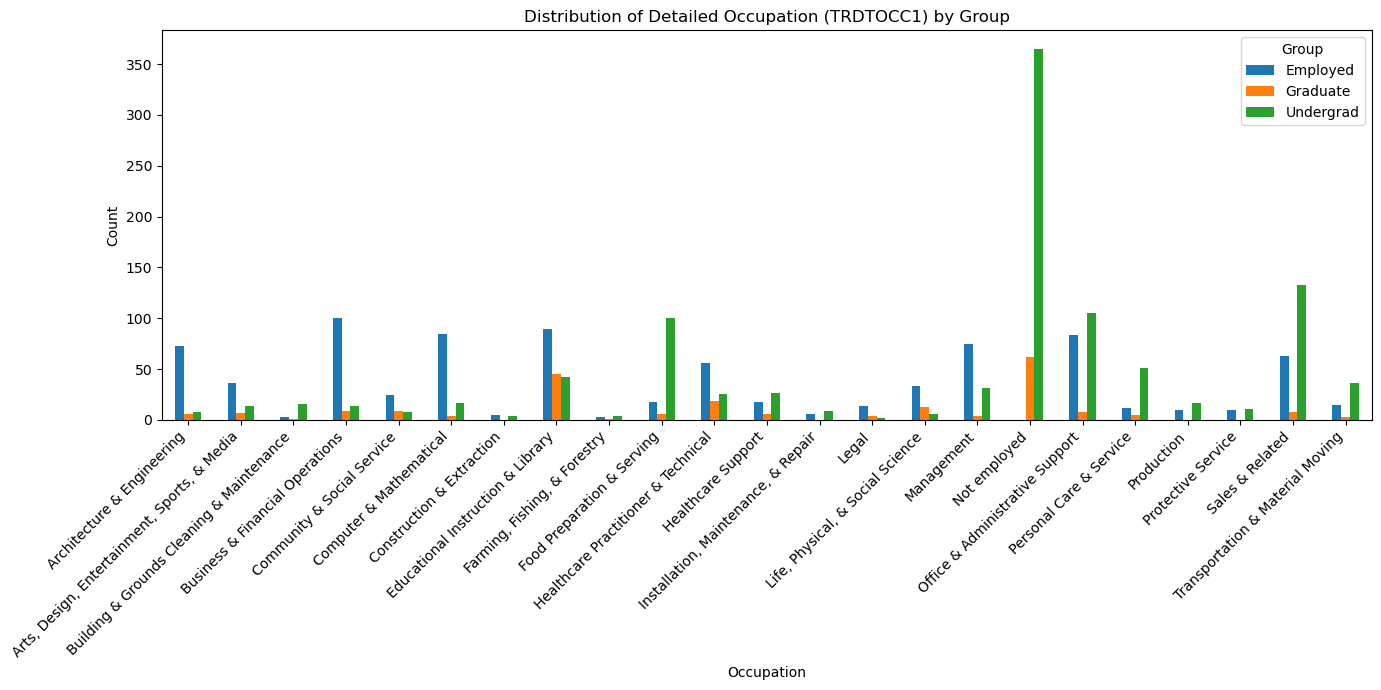

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Detailed occupation code labels (TRDTOCC1)
occ_detail_labels = {
    -1: "Not employed",
    1: "Management",
    2: "Business & Financial Operations",
    3: "Computer & Mathematical",
    4: "Architecture & Engineering",
    5: "Life, Physical, & Social Science",
    6: "Community & Social Service",
    7: "Legal",
    8: "Educational Instruction & Library",
    9: "Arts, Design, Entertainment, Sports, & Media",
    10: "Healthcare Practitioner & Technical",
    11: "Healthcare Support",
    12: "Protective Service",
    13: "Food Preparation & Serving",
    14: "Building & Grounds Cleaning & Maintenance",
    15: "Personal Care & Service",
    16: "Sales & Related",
    17: "Office & Administrative Support",
    18: "Farming, Fishing, & Forestry",
    19: "Construction & Extraction",
    20: "Installation, Maintenance, & Repair",
    21: "Production",
    22: "Transportation & Material Moving"
}

# Map codes to labels
plot_df = final_df.copy()
plot_df["Occupation"] = plot_df["TRDTOCC1"].map(occ_detail_labels).fillna("Unknown")

fig, ax = plt.subplots(figsize=(14, 7))
occ_counts = plot_df.groupby(["group", "Occupation"]).size().unstack(fill_value=0)
occ_counts.T.plot(kind="bar", ax=ax)
ax.set_xlabel("Occupation")
ax.set_ylabel("Count")
ax.set_title("Distribution of Detailed Occupation (TRDTOCC1) by Group")
ax.legend(title="Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

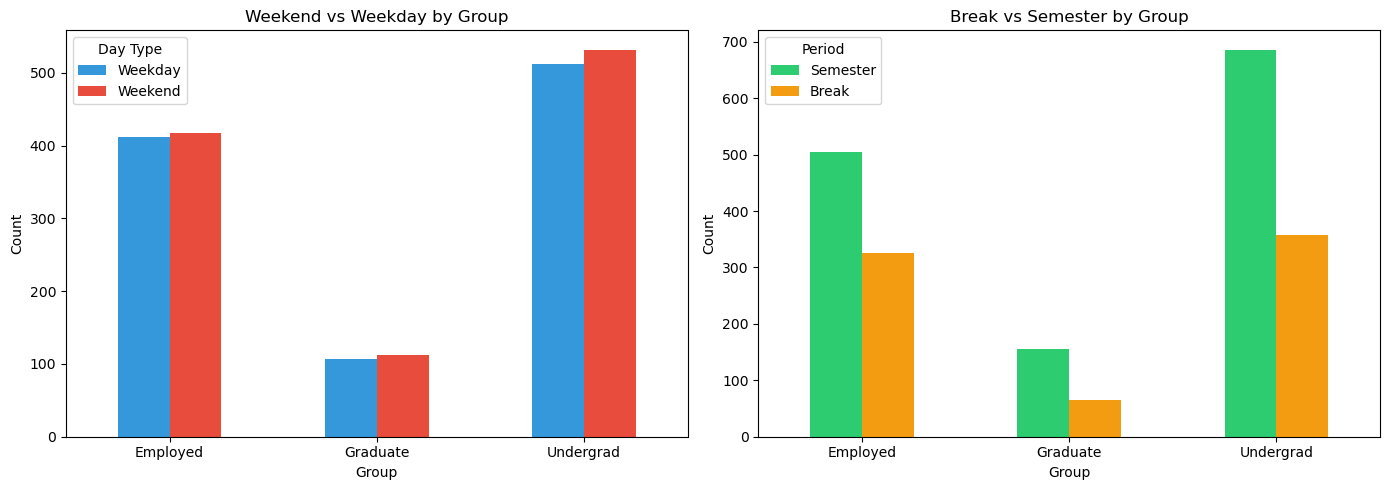

Weekend vs Weekday by Group:
is_weekend  Weekday  Weekend   All
group                             
Employed        412      418   830
Graduate        107      113   220
Undergrad       512      532  1044
All            1031     1063  2094

Break vs Semester by Group:
is_break   Break  Semester   All
group                           
Employed     326       504   830
Graduate      65       155   220
Undergrad    358       686  1044
All          749      1345  2094


In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekend vs Weekday by group
weekend_counts = final_df.groupby(["group", "is_weekend"]).size().unstack(fill_value=0)
weekend_counts.columns = ["Weekday", "Weekend"]
weekend_counts.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"])
axes[0].set_title("Weekend vs Weekday by Group")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("Count")
axes[0].legend(title="Day Type")
axes[0].tick_params(axis='x', rotation=0)

# Break vs Semester by group
break_counts = final_df.groupby(["group", "is_break"]).size().unstack(fill_value=0)
break_counts.columns = ["Semester", "Break"]
break_counts.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#f39c12"])
axes[1].set_title("Break vs Semester by Group")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Count")
axes[1].legend(title="Period")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Crosstab summaries
print("Weekend vs Weekday by Group:")
print(pd.crosstab(final_df["group"], final_df["is_weekend"].map({0: "Weekday", 1: "Weekend"}), margins=True))
print(f"\nBreak vs Semester by Group:")
print(pd.crosstab(final_df["group"], final_df["is_break"].map({0: "Semester", 1: "Break"}), margins=True))

In [45]:
final_df.columns

Index(['TUCASEID', 'group', 'TEAGE', 'TESEX', 'PRMJOCC1', 'TRDTOCC1', 'year',
       'is_weekend', 'is_break', 'volunteer_activities',
       'professional_and_personal_services', 'work_and_work_related',
       'household_activities', 'caring_for_nonhh_members',
       'caring_for_hh_members', 'traveling', 'sports_exercise_recreation',
       'socializing_relaxing_leisure', 'telephone_calls', 'household_services',
       'government_services_and_civic', 'religious_spiritual_activities',
       'consumer_purchases', 'personal_care', 'education', 'data_codes',
       'eating_and_drinking'],
      dtype='object')

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# --- Prepare modeling dataframe ---
model_df = final_df.copy()

# Activity columns (from final_df)
activity_categories = [v for v in major_code_map.values() if v in final_df.columns]

# Build feature matrix: age, sex, weekend, break, and activity time categories
X = pd.concat([
    model_df[["TEAGE", "TESEX", "is_weekend", "is_break"]],
    model_df[activity_categories]
], axis=1).astype(float)

# Encode the target
y = model_df["group"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeatures: {list(X.columns)}")

Feature matrix shape: (2094, 22)
Target distribution:
group
Undergrad    1044
Employed      830
Graduate      220
Name: count, dtype: int64

Features: ['TEAGE', 'TESEX', 'is_weekend', 'is_break', 'personal_care', 'household_activities', 'caring_for_hh_members', 'caring_for_nonhh_members', 'work_and_work_related', 'education', 'consumer_purchases', 'professional_and_personal_services', 'household_services', 'government_services_and_civic', 'eating_and_drinking', 'socializing_relaxing_leisure', 'sports_exercise_recreation', 'religious_spiritual_activities', 'volunteer_activities', 'telephone_calls', 'traveling', 'data_codes']


In [47]:
# --- Multinomial Logistic Regression with statsmodels (for coefficients & p-values) ---

# Standardize continuous features for numerical stability
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_const = sm.add_constant(X_scaled)

# Fit multinomial logit (reference category = alphabetically first = "Employed")
mnlogit_model = sm.MNLogit(y, X_const)
result = mnlogit_model.fit(method='lbfgs', maxiter=500, disp=True)

print(result.summary())

                          MNLogit Regression Results                          
Dep. Variable:                  group   No. Observations:                 2094
Model:                        MNLogit   Df Residuals:                     2048
Method:                           MLE   Df Model:                           44
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.4092
Time:                        13:43:08   Log-Likelihood:                -1175.9
converged:                       True   LL-Null:                       -1990.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    group=Graduate       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -0.6341      2.221     -0.286      0.775      -4.987       3.719
TEAGE                                 -0.3882      0.125   

In [48]:
# --- Extract significant predictors (p < 0.05) ---
import matplotlib.pyplot as plt

params = result.params
pvalues = result.pvalues

# params/pvalues have shape (n_features, K-1) — one column per non-reference group
group_labels = params.columns.tolist()

sig_results = []
for col_idx, group_label in enumerate(group_labels):
    for feat in params.index:
        pval = pvalues.loc[feat, group_label]
        if pval < 0.05 and feat != "const":
            sig_results.append({
                "group_vs_reference": group_label,
                "feature": feat,
                "coefficient": params.loc[feat, group_label],
                "p_value": pval
            })

sig_df = pd.DataFrame(sig_results).sort_values("p_value")
print(f"Significant predictors (p < 0.05): {len(sig_df)}")
sig_df

Significant predictors (p < 0.05): 8


,group_vs_reference,feature,coefficient,p_value
2,1,TEAGE,-2.133602,4.394746e-98
5,1,education,3.257092,1.631244e-09
3,1,caring_for_hh_members,0.581827,2.492366e-05
0,0,TEAGE,-0.388212,1.945152e-03
1,0,education,4.171501,1.077825e-02
4,1,caring_for_nonhh_members,0.303302,1.529692e-02
7,1,data_codes,0.307756,1.655968e-02
6,1,volunteer_activities,0.287047,2.415429e-02
